<a href="https://colab.research.google.com/github/xanderteng/MLRain/blob/main/notebook/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!git clone https://github.com/xanderteng/MLRain.git
%cd MLRain

Cloning into 'MLRain'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 40 (delta 11), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 3.50 MiB | 15.37 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/MLRain/MLRain


In [10]:
import pandas as pd

try:
    df = pd.read_csv('data/raw/historic.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'data/raw/historic.csv' tidak ditemukan.")

,Timestamp,Temperature,Humidity,Cloud_Cover,Pressure,Wind_Speed,Location,Latitude,Longitude,Rain
0,2023-04-01T00:00,24.5,88,100,1006.6,13.7,Alam_Sutera,-6.2226,106.6533,0
1,2023-04-01T01:00,25.7,85,100,1007.5,20.0,Alam_Sutera,-6.2226,106.6533,1
2,2023-04-01T02:00,25.4,83,100,1007.8,15.1,Alam_Sutera,-6.2226,106.6533,1
3,2023-04-01T03:00,27.6,75,100,1007.5,19.9,Alam_Sutera,-6.2226,106.6533,1
4,2023-04-01T04:00,28.6,74,100,1006.9,17.5,Alam_Sutera,-6.2226,106.6533,1


### Step 1: Data Overview and Summary Statistics
We will check the dimensions of the dataset, data types, and identify any missing values.

In [11]:
# Check basic info, duplicates, and missing values
print("Dataset Info:")
display(df.info())

print("\nDuplicate Rows:")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236952 entries, 0 to 236951
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Timestamp    236952 non-null  object 
 1   Temperature  236952 non-null  float64
 2   Humidity     236952 non-null  int64  
 3   Cloud_Cover  236952 non-null  int64  
 4   Pressure     236952 non-null  float64
 5   Wind_Speed   236952 non-null  float64
 6   Location     236952 non-null  object 
 7   Latitude     236952 non-null  float64
 8   Longitude    236952 non-null  float64
 9   Rain         236952 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 18.1+ MB


None


Duplicate Rows:
Total duplicate rows: 0

Missing Values:


,0
Timestamp,0
Temperature,0
Humidity,0
Cloud_Cover,0
Pressure,0
Wind_Speed,0
Location,0
Latitude,0
Longitude,0
Rain,0



Descriptive Statistics:


,Timestamp,Temperature,Humidity,Cloud_Cover,Pressure,Wind_Speed,Location,Latitude,Longitude,Rain
count,236952,236952.000000,236952.000000,236952.000000,236952.000000,236952.000000,236952,236952.000000,236952.000000,236952.000000
unique,26328,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN
top,2026-04-01T23:00,NaN,NaN,NaN,NaN,NaN,Alam_Sutera,NaN,NaN,NaN
freq,9,NaN,NaN,NaN,NaN,NaN,26328,NaN,NaN,NaN
mean,NaN,27.017491,80.979502,79.194647,1006.215601,6.593264,NaN,-6.244467,106.644567,0.321251
std,NaN,2.927258,14.554819,31.708749,2.397151,4.102803,NaN,0.052002,0.059308,0.466958
min,NaN,19.500000,21.000000,0.000000,996.200000,0.000000,NaN,-6.340700,106.517300,0.000000
25%,NaN,24.700000,72.000000,65.000000,1004.700000,3.700000,NaN,-6.273800,106.628500,0.000000
50%,NaN,26.200000,85.000000,99.000000,1006.300000,5.500000,NaN,-6.241600,106.653300,0.000000
75%,NaN,29.100000,93.000000,100.000000,1007.900000,8.600000,NaN,-6.222600,106.657900,1.000000


####NO MISSING VALUE


Data Preprocessing


In [12]:
# convert timestamp to datetime

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("New Timestamp dtype:", df['Timestamp'].dtype)
display(df[['Timestamp']].head())

New Timestamp dtype: datetime64[ns]


,Timestamp
0,2023-04-01 00:00:00
1,2023-04-01 01:00:00
2,2023-04-01 02:00:00
3,2023-04-01 03:00:00
4,2023-04-01 04:00:00


### Numerical Distribution Analysis


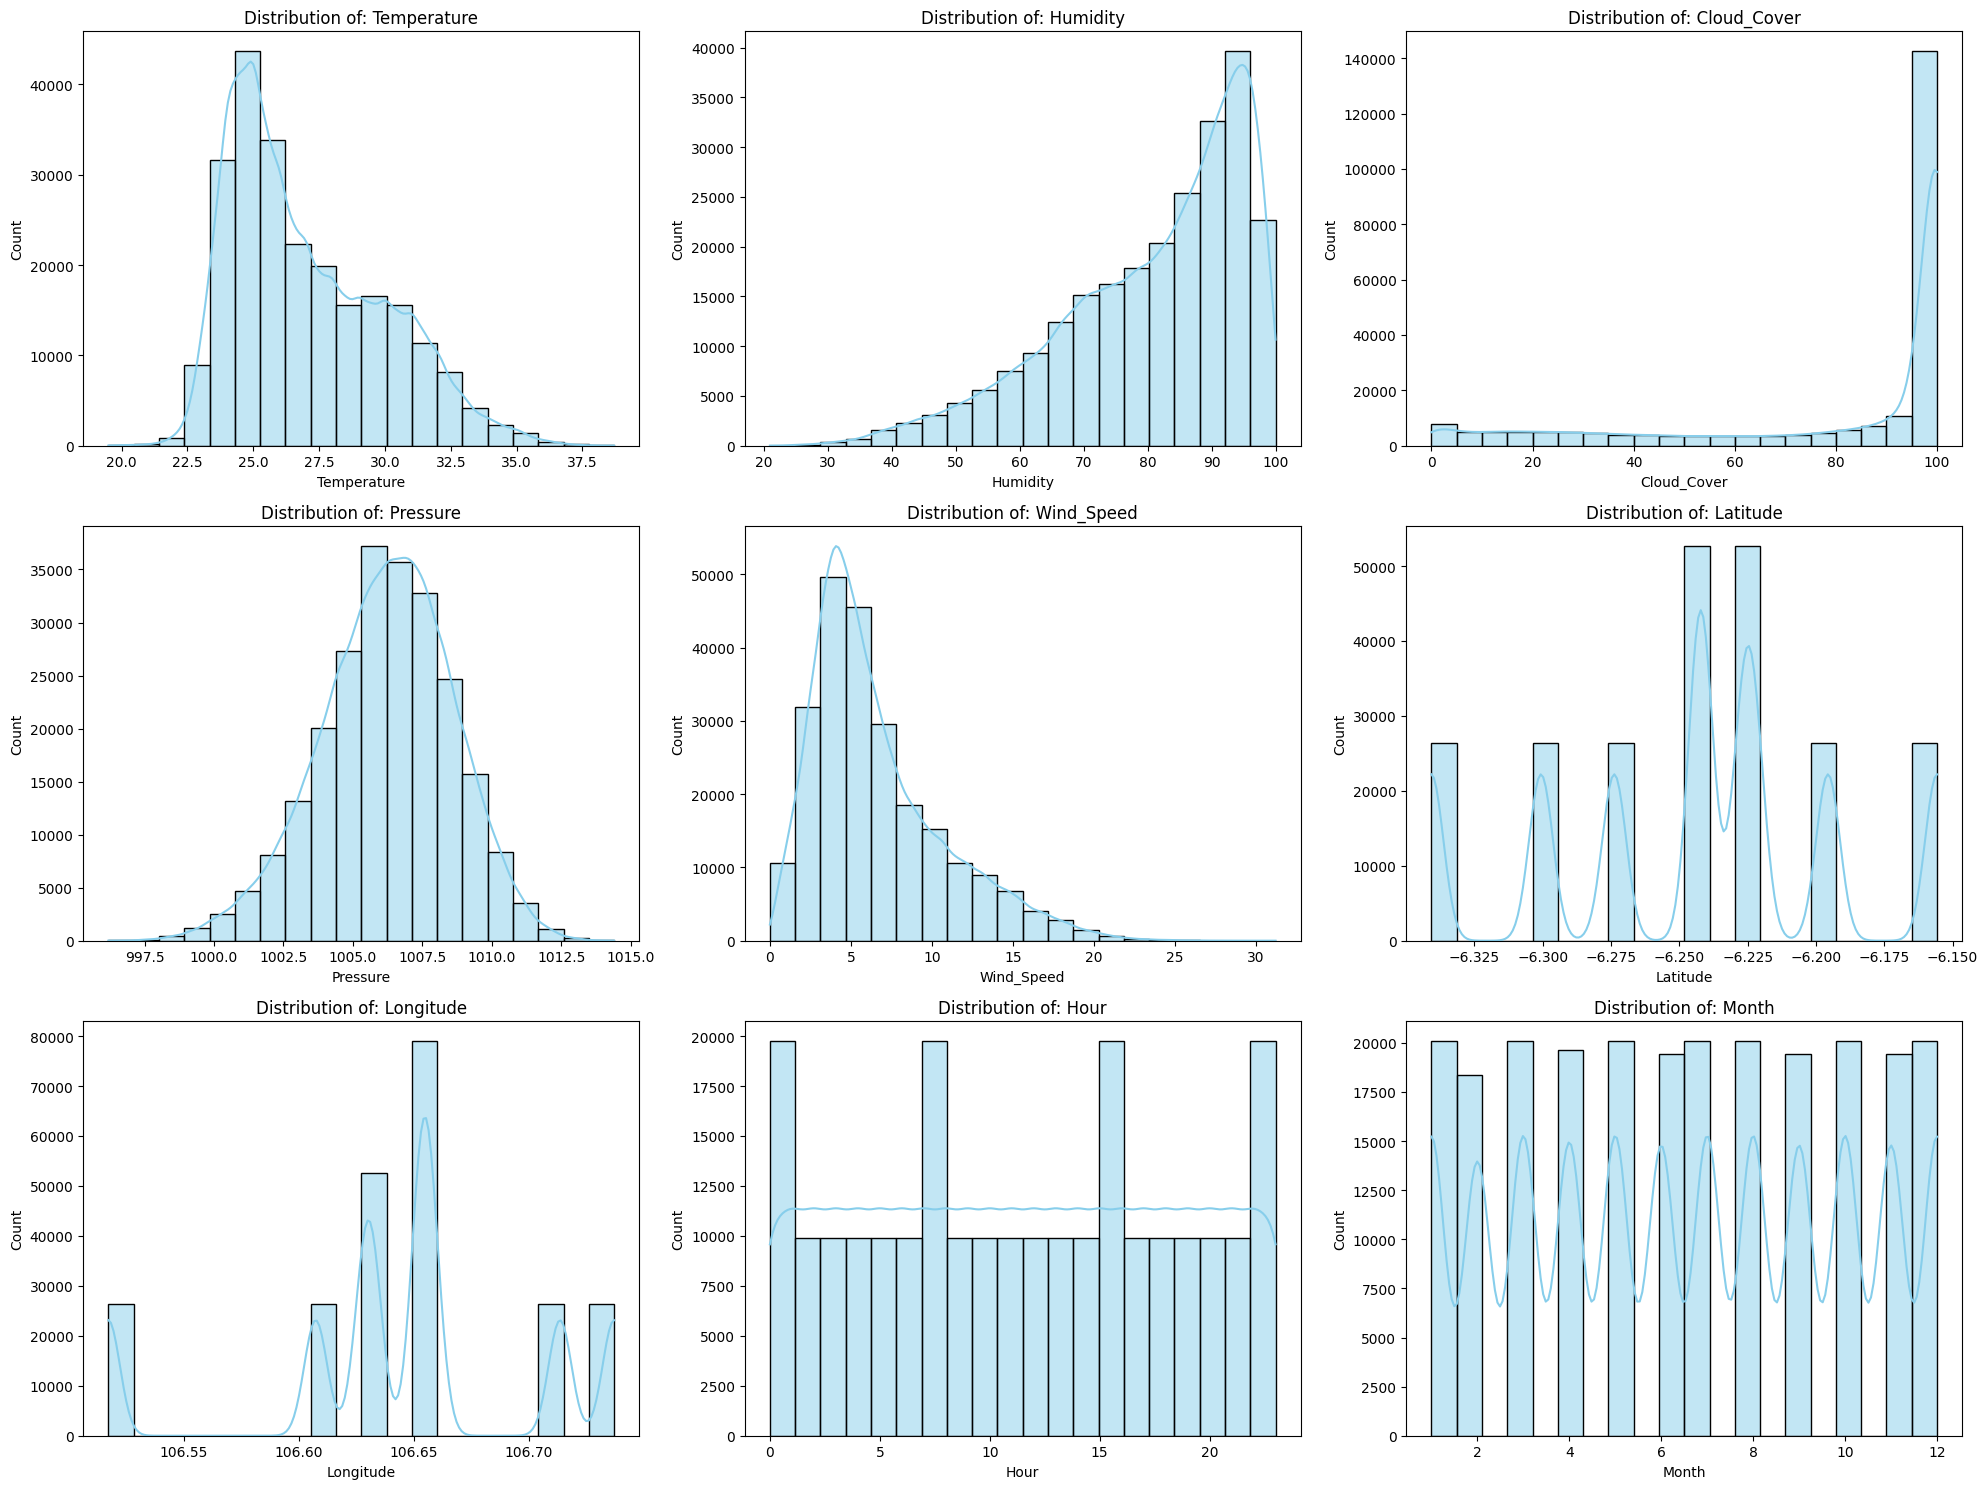

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting temporal features first so they exist for the plotting list
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month

# Complete list of numerical columns to prove we aren't ignoring anything
all_numerical = ['Temperature', 'Humidity', 'Cloud_Cover', 'Pressure', 'Wind_Speed', 'Latitude', 'Longitude', 'Hour', 'Month']

plt.figure(figsize=(20, 15))
for i, col in enumerate(all_numerical, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribution of: {col}')

plt.tight_layout()
plt.show()

### Distribution Analysis Summary

*   **Temperature**: Relatively symmetric and stable; most observations fall within a narrow comfort range.
*   **Humidity**: Strongly left-skewed, reflecting consistently high moisture levels in the dataset's focus areas.
*   **Cloud Cover**: Shows a bimodal pattern, frequently peaking at 0% (clear) and 100% (overcast).
*   **Pressure**: Highly concentrated with very low variance, where even small shifts can signal weather changes.
*   **Wind Speed**: Right-skewed, with a majority of low-speed days and occasional high-speed weather events.
*   **Spatial (Lat/Long)**: Identifies distinct geographical clusters corresponding to the specific monitoring locations.
*   **Temporal (Hour/Month)**: Uniformly distributed across hours and months, ensuring we have a balanced temporal representation.

### Correlation Analysis
We will calculate the correlation matrix and visualize it using a heatmap to identify strong relationships between features.

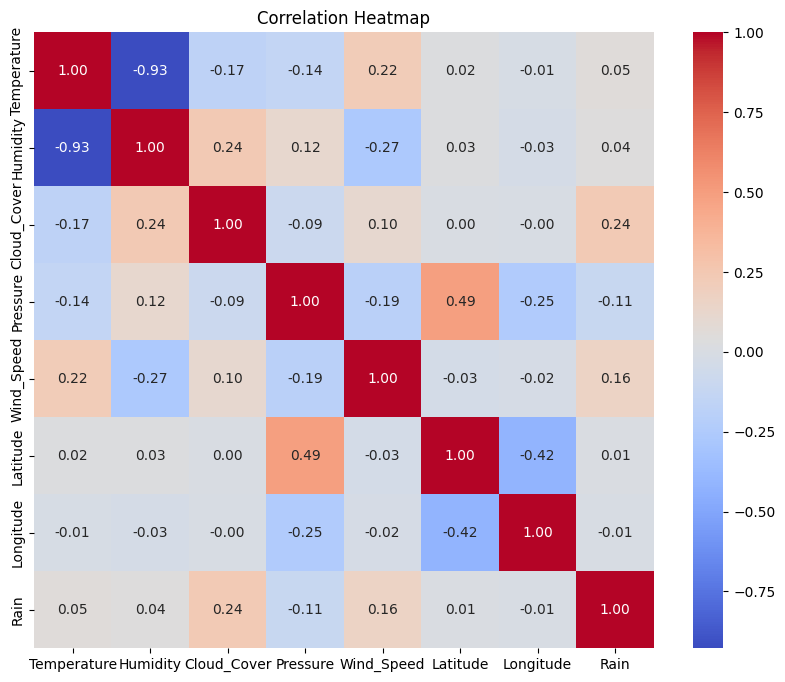

In [14]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Analysis Summary

*   **Strong Negative Correlation (Temp vs Humidity)**: A very strong inverse relationship exists between Temperature and Humidity, which is expected in atmospheric physics.
*   **Cloud Cover**: Shows a moderate positive correlation with Rain and Humidity, reinforcing its role in precipitation events.
*   **Wind Speed and Pressure**: These features show very low linear correlation with other variables, suggesting their influence might be non-linear or dependent on complex interactions.

### Step 5: Relationship with Target Variable (Rain)
We will use boxplots to visualize how numerical features like Temperature and Humidity differ based on whether it is raining or not.

/tmp/ipykernel_7443/1858652263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rain', y=col, data=df, palette='Set2')
/tmp/ipykernel_7443/1858652263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rain', y=col, data=df, palette='Set2')
/tmp/ipykernel_7443/1858652263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rain', y=col, data=df, palette='Set2')
/tmp/ipykernel_7443/1858652263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

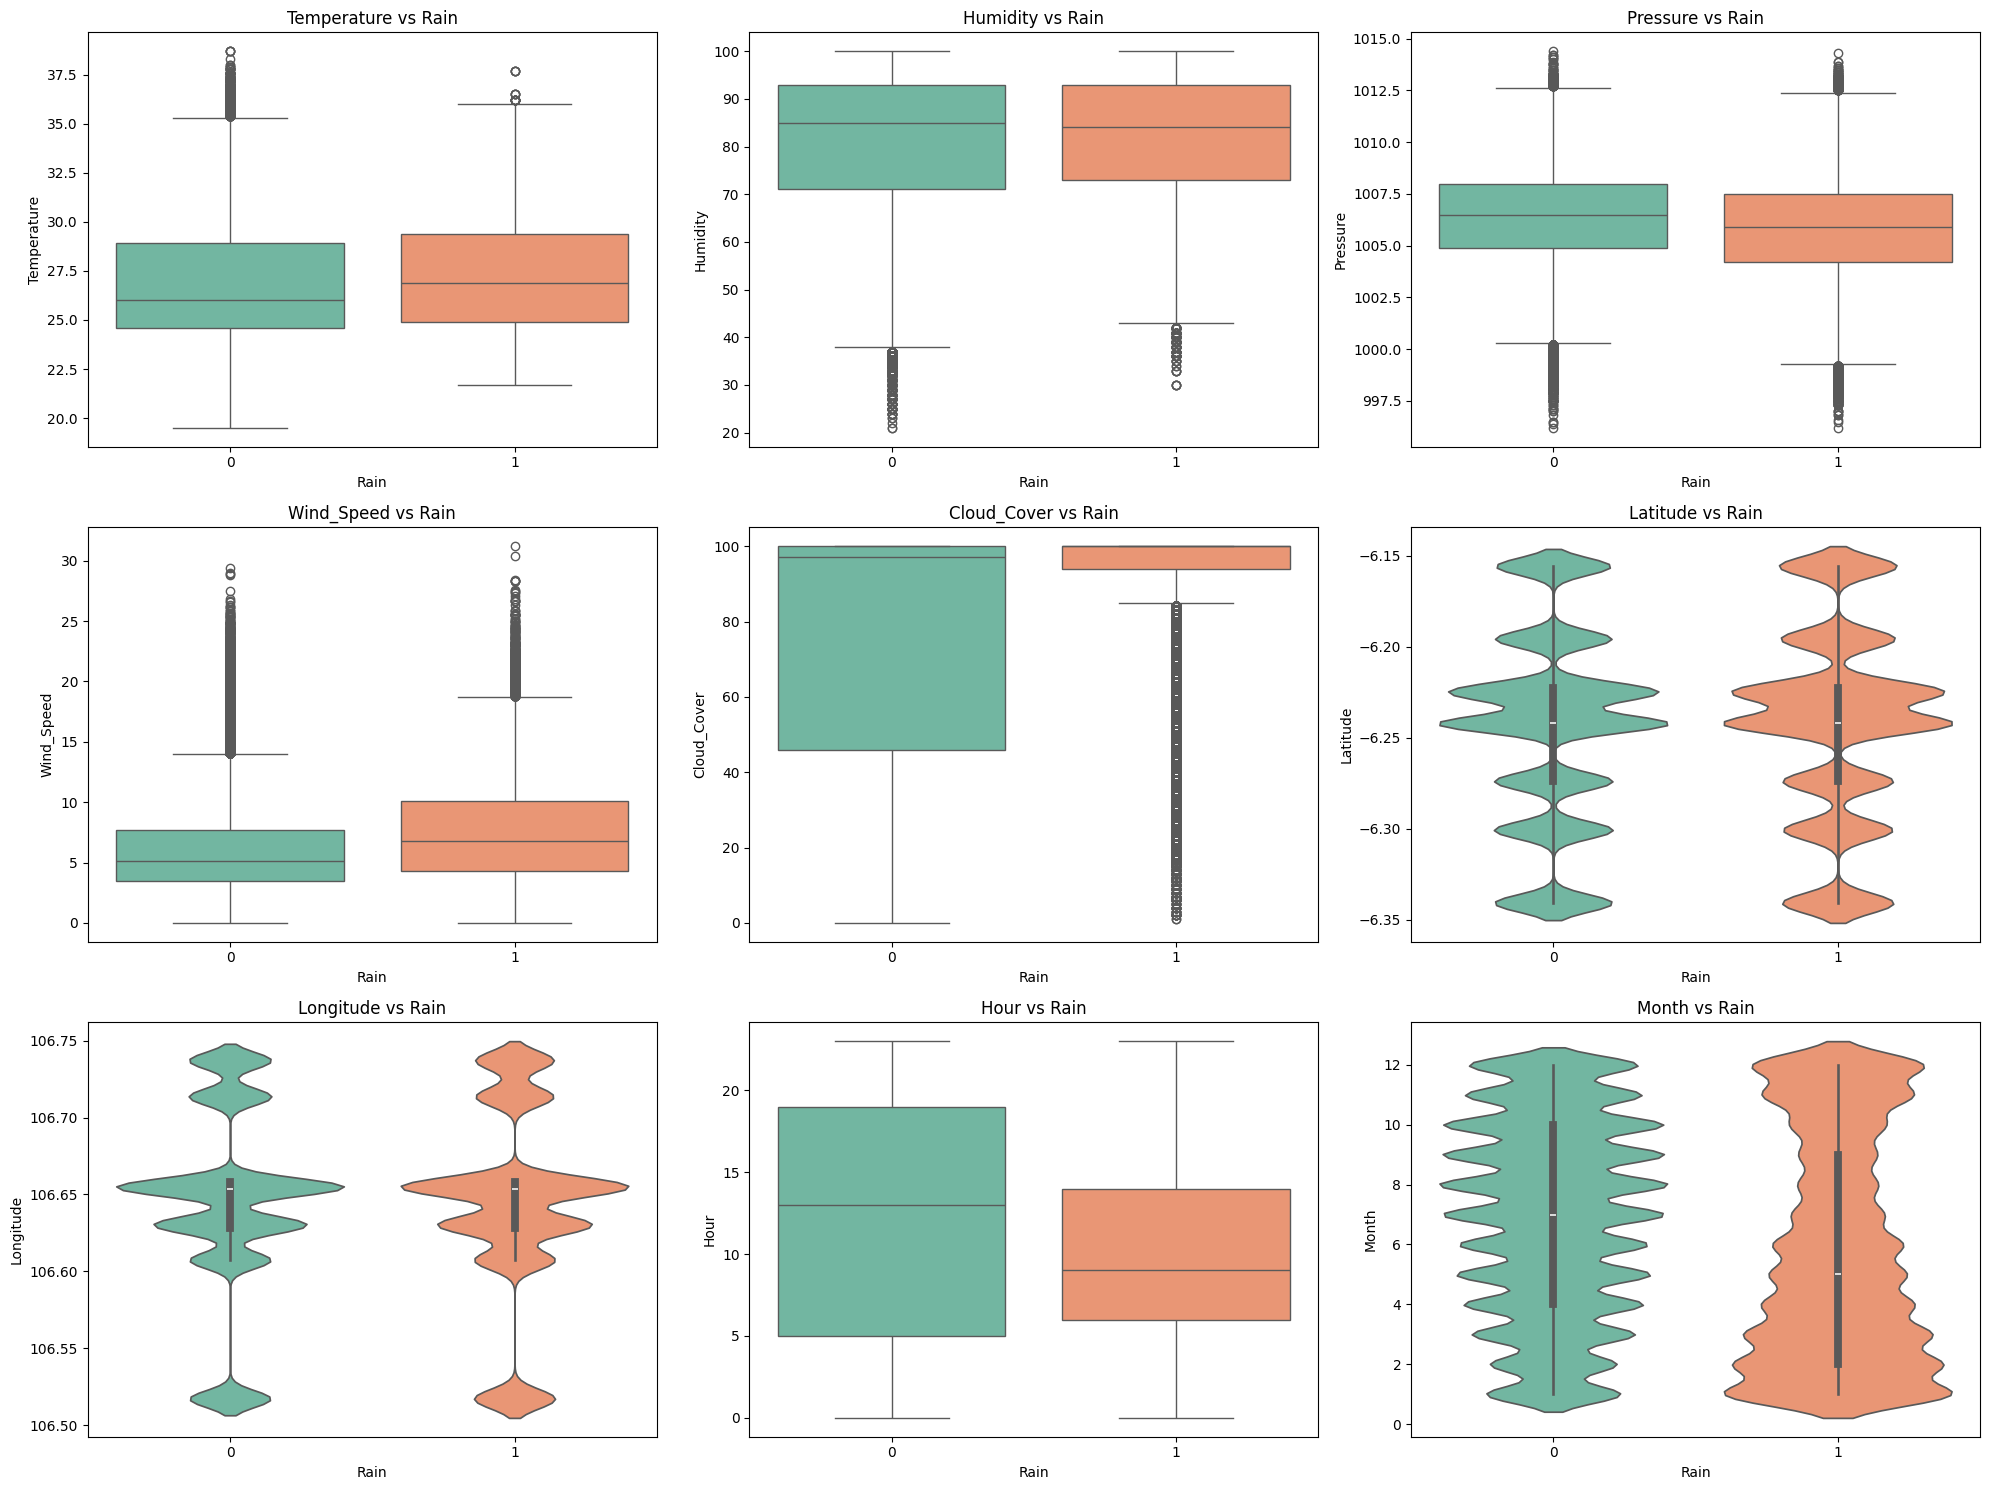

In [15]:
plt.figure(figsize=(20, 15))
# Expanding to include all numerical features we've discussed
features_to_plot = ['Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'Cloud_Cover', 'Latitude', 'Longitude', 'Hour', 'Month']

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    if df[col].nunique() > 20:
        sns.boxplot(x='Rain', y=col, data=df, palette='Set2')
    else:
        # For features with fewer unique values (like Hour/Month), a violin plot can show density better
        sns.violinplot(x='Rain', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Rain')

plt.tight_layout()
plt.show()

### Summary of Relationship with Target (Rain)

*   **Primary Predictors**: **Humidity** and **Cloud Cover** show the most significant distributional shifts. Rain occurs almost exclusively at very high humidity levels and high cloud cover.
*   **Secondary Factors**: **Temperature** tends to be slightly lower during rain events (likely due to cloud cover), and **Pressure** shows a minor decrease in median value during rain.
*   **Weak/Non-Linear Predictors**: **Wind Speed**, **Latitude**, and **Longitude** show nearly identical distributions for both classes. This suggests they have low individual predictive power and may only be useful in non-linear combinations.
*   **Temporal Patterns**: The probability of rain across different **Hours** and **Months** is relatively flat in these specific box/violin plots, suggesting no single time period is a 'silver bullet' for prediction without looking at other features.

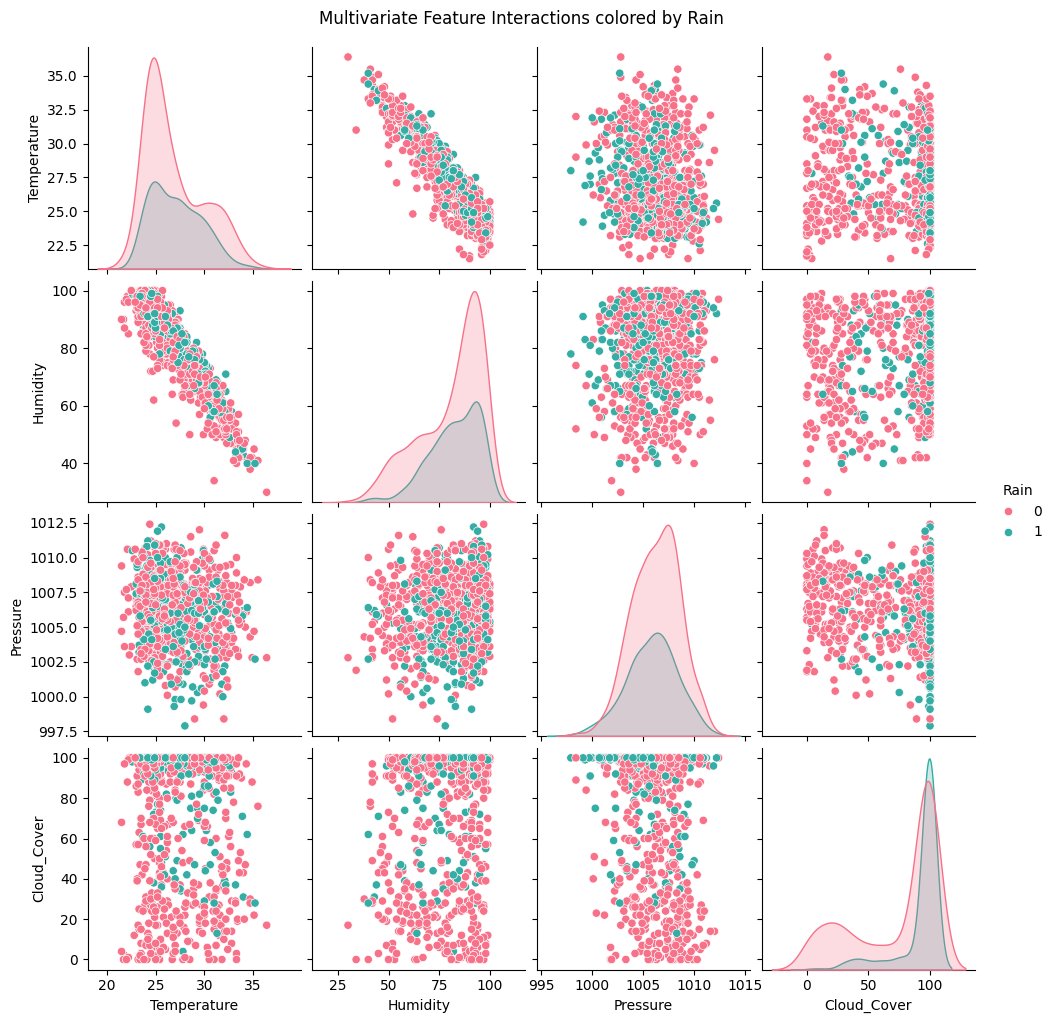

In [16]:
# 2. Multivariate Interaction (Sampled for performance)
# Looking at how multiple features separate the 'Rain' classes
sample_df = df.sample(n=1000, random_state=42)

sns.pairplot(sample_df, vars=['Temperature', 'Humidity', 'Pressure', 'Cloud_Cover'], hue='Rain', diag_kind='kde', palette='husl')
plt.suptitle('Multivariate Feature Interactions colored by Rain', y=1.02)
plt.show()

The pairplot shows that while no single feature perfectly separates 'Rain' from 'No Rain', combinations of High Humidity and specific Pressure levels create visible clusters where rain is much more likely.


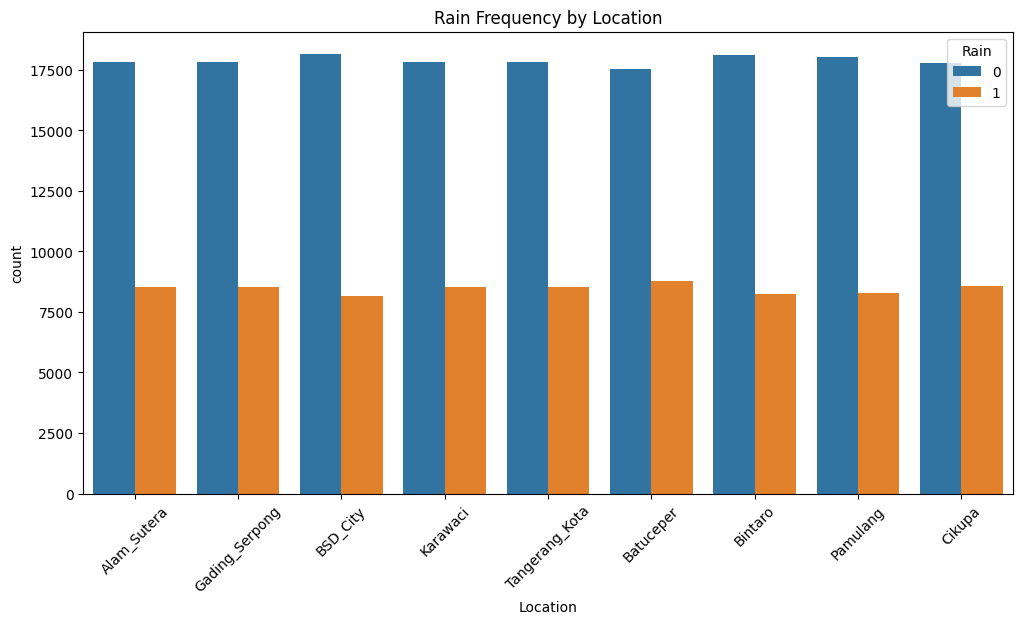

Percentage of Rain by Location:
Location
Batuceper         33.348526
Cikupa            32.478730
Alam_Sutera       32.379976
Karawaci          32.379976
Gading_Serpong    32.379976
Tangerang_Kota    32.379976
Pamulang          31.502583
Bintaro           31.278487
BSD_City          30.997417
Name: Rain, dtype: float64


In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Location', hue='Rain')
plt.title('Rain Frequency by Location')
plt.xticks(rotation=45)
plt.show()

# calculate rain percentage per location
rain_prop = df.groupby('Location')['Rain'].mean().sort_values(ascending=False) * 100
print("Percentage of Rain by Location:")
print(rain_prop)

### Time-Series Analysis
We will extract temporal features (Hour and Month) to identify seasonal or daily patterns in rainfall.

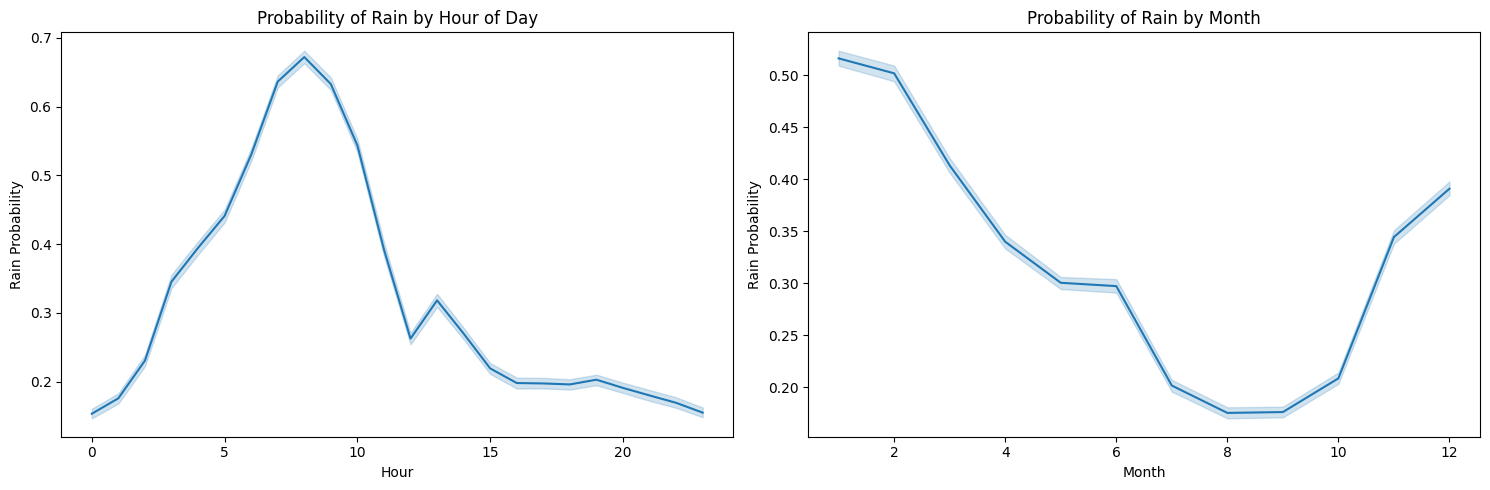

In [18]:
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month

plt.figure(figsize=(15, 5))

# Hourly Rain Trend
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Hour', y='Rain', estimator='mean')
plt.title('Probability of Rain by Hour of Day')
plt.ylabel('Rain Probability')

# Monthly Rain Trend
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='Month', y='Rain', estimator='mean')
plt.title('Probability of Rain by Month')
plt.ylabel('Rain Probability')

plt.tight_layout()
plt.show()

### Outlier Detection
We will use boxplots to identify potential outliers in the numerical variables, which could represent extreme weather events or data entry errors.

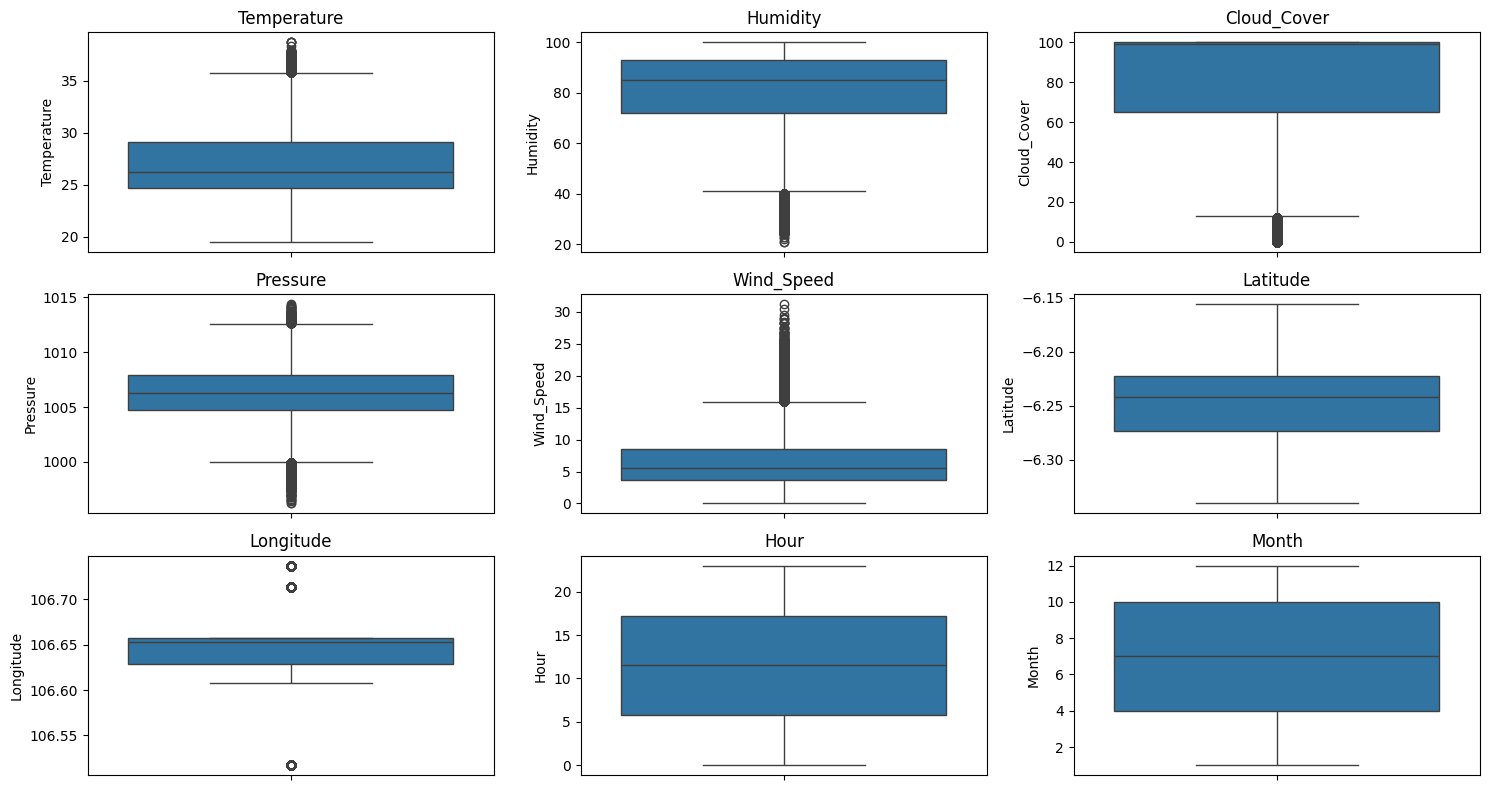

In [23]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(all_numerical, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

### Summary of Feature Distributions

*   **Temperature**: Highly stable and approximately normally distributed. It has the lowest variance and fewest outliers.
*   **Humidity**: Strongly left-skewed, indicating consistently high moisture levels in these locations.
*   **Cloud Cover**: Distinctly **bimodal**. The high outlier count is a result of the data frequently hitting 0% (clear sky) or 100% (full cover), rather than being 'errors'.
*   **Pressure**: Very tight distribution. Even minor deviations (outliers) are significant for weather prediction.
*   **Wind Speed**: Right-skewed. Most days have low wind, but the 'outliers' represent important extreme weather events.

In [25]:
outlier_results = {}

for col in all_numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_results[col] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_results).T
display(outlier_df)

,count,percentage
Temperature,663.0,0.279804
Humidity,2671.0,1.127233
Cloud_Cover,15666.0,6.611466
Pressure,2181.0,0.920440
Wind_Speed,8539.0,3.603683
Latitude,0.0,0.000000
Longitude,78984.0,33.333333
Hour,0.0,0.000000
Month,0.0,0.000000


Identified significant outliers in Cloud Cover (6.6%) and Wind Speed (3.6%), representing valid weather extremes rather than errors.


### Statistical Shape (Skewness & Kurtosis)


In [27]:
stats_shape = pd.DataFrame({
    'Skewness': df[all_numerical].skew(),
    'Kurtosis': df[all_numerical].kurt()
})

print("Distribution Shape Metrics:")
display(stats_shape)

# Quick Interpretation
print("\nInterpretation:")
print("- Skewness > 0: Right-skewed (e.g., Wind Speed)")
print("- Skewness < 0: Left-skewed (e.g., Humidity)")
print("- Kurtosis > 3: Heavy tails (more outliers)")

Distribution Shape Metrics:


,Skewness,Kurtosis
Temperature,0.709334,-0.292012
Humidity,-0.927067,0.243513
Cloud_Cover,-1.311749,0.186062
Pressure,-0.274912,0.017126
Wind_Speed,1.139304,1.085286
Latitude,-0.206447,-0.499838
Longitude,-0.529211,0.236759
Hour,0.000000,-1.204174
Month,-0.007261,-1.208263



Interpretation:
- Skewness > 0: Right-skewed (e.g., Wind Speed)
- Skewness < 0: Left-skewed (e.g., Humidity)
- Kurtosis > 3: Heavy tails (more outliers)


Confirmed observations mathematically; Wind Speed has high Skewness (>1), and Cloud Cover has the strongest negative Skewness (-1.31).

### Preprocessing: Categorical Encoding
We convert the 'Location' column from text to numerical labels so the model can interpret them.

In [28]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode Location
df['Location_Encoded'] = le.fit_transform(df['Location'])

# Display the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Location Mapping:")
print(mapping)

display(df[['Location', 'Location_Encoded']].head())

Location Mapping:
{'Alam_Sutera': np.int64(0), 'BSD_City': np.int64(1), 'Batuceper': np.int64(2), 'Bintaro': np.int64(3), 'Cikupa': np.int64(4), 'Gading_Serpong': np.int64(5), 'Karawaci': np.int64(6), 'Pamulang': np.int64(7), 'Tangerang_Kota': np.int64(8)}


,Location,Location_Encoded
0,Alam_Sutera,0
1,Alam_Sutera,0
2,Alam_Sutera,0
3,Alam_Sutera,0
4,Alam_Sutera,0


### Preprocessing: Cyclical Encoding
We transform 'Hour' and 'Month' using sine and cosine functions to preserve their cyclical relationships.

In [29]:
import numpy as np

# Cyclical encoding for Hour (24-hour cycle)
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# Cyclical encoding for Month (12-month cycle)
df['month_sin'] = np.sin(2 * np.pi * (df['Month']-1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['Month']-1) / 12)

# Drop the original redundant columns to keep the dataset clean for modeling
# We will keep them for now to verify the transformation, then drop them in the final step.
display(df[['Hour', 'hour_sin', 'hour_cos', 'Month', 'month_sin', 'month_cos']].head())

,Hour,hour_sin,hour_cos,Month,month_sin,month_cos
0,0,0.000000,1.000000,4,1.0,6.123234e-17
1,1,0.258819,0.965926,4,1.0,6.123234e-17
2,2,0.500000,0.866025,4,1.0,6.123234e-17
3,3,0.707107,0.707107,4,1.0,6.123234e-17
4,4,0.866025,0.500000,4,1.0,6.123234e-17


### Preprocessing: Feature Scaling
We apply Standard Scaling to our numerical features to normalize their ranges.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = ['Temperature', 'Humidity', 'Cloud_Cover', 'Pressure', 'Wind_Speed']

# Create a copy for the scaled values
df_scaled = df.copy()
df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

print("Features scaled successfully.")
display(df_scaled[numerical_features].head())

Features scaled successfully.


,Temperature,Humidity,Cloud_Cover,Pressure,Wind_Speed
0,-0.860019,0.482350,0.656141,0.160357,1.732170
1,-0.450078,0.276232,0.656141,0.535803,3.267709
2,-0.552563,0.138820,0.656141,0.660952,2.073401
3,0.198995,-0.410827,0.656141,0.535803,3.243335
4,0.540613,-0.479533,0.656141,0.285506,2.658368


### Preprocessing: Power Transformation (Handling Skewness)
Since we identified skewness in columns like `Wind_Speed` and `Humidity`, we apply a Yeo-Johnson transformation to stabilize variance and make the data more Gaussian-like.

In [31]:
from sklearn.preprocessing import PowerTransformer

# Initialize PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

# Apply transformation to the already scaled numerical features
df_scaled[numerical_features] = pt.fit_transform(df_scaled[numerical_features])

print("Power transformation applied to handle skewness.")
# Re-check skewness to see the improvement
display(df_scaled[numerical_features].skew().to_frame('New Skewness'))

Power transformation applied to handle skewness.


,New Skewness
Temperature,0.084903
Humidity,-0.143449
Cloud_Cover,-0.707031
Pressure,-0.001165
Wind_Speed,0.062926


### Preprocessing Final Feature Selection
We select our processed features and the target variable 'Rain' to create our final training dataset.

In [32]:
# Define the final list of features to use
final_features = [
    'Temperature', 'Humidity', 'Cloud_Cover', 'Pressure', 'Wind_Speed',
    'Location_Encoded', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# Prepare the final feature matrix (X) and target vector (y)
X = df_scaled[final_features]
y = df_scaled['Rain']

print(f"Final Feature Set: {final_features}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
display(X.head())

Final Feature Set: ['Temperature', 'Humidity', 'Cloud_Cover', 'Pressure', 'Wind_Speed', 'Location_Encoded', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
Shape of X: (236952, 10)
Shape of y: (236952,)


,Temperature,Humidity,Cloud_Cover,Pressure,Wind_Speed,Location_Encoded,hour_sin,hour_cos,month_sin,month_cos
0,-0.899504,0.346857,0.807547,0.109020,1.524110,0,0.000000,1.000000,1.0,6.123234e-17
1,-0.319934,0.064065,0.807547,0.503933,2.177641,0,0.258819,0.965926,1.0,6.123234e-17
2,-0.456832,-0.106923,0.807547,0.639112,1.690180,0,0.500000,0.866025,1.0,6.123234e-17
3,0.411030,-0.655354,0.807547,0.503933,2.168821,0,0.707107,0.707107,1.0,6.123234e-17
4,0.710410,-0.712153,0.807547,0.238750,1.944350,0,0.866025,0.500000,1.0,6.123234e-17
